In [ ]:
# CELL 0
# MOUNTING DRIVE

from google.colab import drive
drive.mount('/content/drive')

# ----------------- CHECKING PATH TO AN IMAGE

import os

# insert the name the your Drive folder which contains a shortcut to the project data
#my_drive_folder = "UNIVR/ADVANCED_PROGRAMMING"
my_drive_folder = "APAI_CVDL_shared"

# expected True if path exists
print(os.path.exists(f"/content/drive/MyDrive/{my_drive_folder}/project/data/pre/img/10674_train_0_.npy"))

Mounted at /content/drive
True


In [ ]:
# CELL 1
# UNZIPPING DATA TO /content/pre

import zipfile
from pathlib import Path
from tqdm import tqdm

DRIVE_ZIP = Path(f"/content/drive/MyDrive/{my_drive_folder}/project/data/pre.zip")
EXTRACT_ROOT = Path("/content/data")

#if not EXTRACT_ROOT.exists(): # heuristic, but good enough
    # create new local data dir if not already present
EXTRACT_ROOT.mkdir(parents=True, exist_ok=True)

    # open the zip from Drive in read mode
with zipfile.ZipFile(DRIVE_ZIP, "r") as z:
        # list of zipped objects
    objects = z.infolist()

        # total number of zipped objects
    total = len(objects)

    for o in tqdm(objects, total=total, desc="unzipping"):
            # unzip
      z.extract(o, EXTRACT_ROOT)
#else:
    #print("data already extracted, skipping step")

unzipping: 100%|██████████| 24098/24098 [01:09<00:00, 344.53it/s]


In [ ]:
# CELL 2
# LOADING THE MANIFEST

import os

# build the path to the correct manifest file
META_DIR = f"/content/drive/MyDrive/{my_drive_folder}/project/meta"

# build the path to the correct manifest file
manifest_path = f"{META_DIR}/manifest.parquet"

LOCAL_MANIFEST=f"{META_DIR}/manifest_local.parquet" #For AL we work on a copy of the manifest, where we modify the entries indicating if they are labeled or not, and in which round each sample is added

# expected True if path exists
print(os.path.exists(manifest_path))

In [ ]:
# CELL 3
# BUILDING THE DATAFRAME

import pandas as pd

# build DataFrame
df = pd.read_parquet(manifest_path)

# print row count and col names from the manifest
print("rows in manifest_preproc.parquet:", len(df))
print("cols in manifest_preproc.parquet:", df.columns.tolist())

# print first 5 rows
df.head(5)

In [ ]:
#CELL 3.5, modifying local manifest

#WORK ON LOCAL MANIFEST FOR AL

from pathlib import Path
import pandas as pd

LOCAL_ROOT = Path("/content/project_data/data")

# original manifest on Drive
df = pd.read_parquet("/content/drive/MyDrive/UNIVR/ADVANCED_PROGRAMMING/project/meta/manifest.parquet")


df.to_parquet(LOCAL_MANIFEST, index=False)
print("Local manifest written:", LOCAL_MANIFEST)

# quick check first 3 exist
for i in range(3):
    print(i, Path(df.loc[i, "img_path"]).exists(), Path(df.loc[i, "mask_path"]).exists(), df.loc[i, "img_path"])

In [ ]:
# CELL 4
# VERIFYING DATA TYPES

import os
import numpy as np
import matplotlib.pyplot as plt

# define root
ROOT = "/content/project_data"

# find first row with a positive mask
idx = 0
for i, row in df.iterrows():
    if "train_1" in row["mask_path"]:
        print("row index:", i)
        idx = i
        break

# assign index
row = df.iloc[idx]

# ----------------- ADAPTING SLASHES TO LINUX

# replace slashes
img_rel_path = row["img_path"].replace("\\", "/")
mask_rel_path = row["mask_path"].replace("\\", "/")

# join paths
img_path  = os.path.join(ROOT, str(img_rel_path))
mask_path = os.path.join(ROOT, str(mask_rel_path))

# check
print("img_path:", img_path)
print("mask_path:", mask_path)

# ----------------- PRINTING AND PLOTTING TO VERIFY DATA

# images and masks from disk to memory
img = np.load(img_path)
mask = np.load(mask_path)

# print dtype info
print("\nIMG  shape/dtype/min/max:", img.shape, img.dtype, img.min(), img.max())
print("MASK shape/dtype/min/max:", mask.shape, mask.dtype, mask.min(), mask.max())
print("MASK unique (first 20):", np.unique(mask)[:20])

# plot
plt.figure()
plt.imshow(img, cmap="gray")
plt.title("Image")
plt.colorbar()
plt.show()

plt.figure()
plt.imshow(mask, cmap="gray")
plt.title("Mask")
plt.colorbar()
plt.show()

In [ ]:
# CELL 5
# CREATING SPLIT DATAFRAMES

# train split
df_train = df[df["split"] == "train"].copy()
# print rows
print("train rows:", len(df_train))

# val split
df_val = df[df["split"] == "val"].copy()
# print rows
print("val rows:", len(df_val))

In [ ]:
# CELL 6
# CREATING THE DATASET CLASS POOL DATASET CLASS

import os
import numpy as np
import torch
from torch.utils.data import Dataset

class BaselineDataset(Dataset):
    def __init__(self, df, root, img_col="img_path", mask_col="mask_path"):
        self.df = df.reset_index(drop=True)
        self.root = root
        self.img_col = img_col
        self.mask_col = mask_col

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]

        # replace slashes and join paths
        img_rel_path = row[self.img_col].replace("\\", "/")
        mask_rel_path = row[self.mask_col].replace("\\", "/")
        img_path  = os.path.join(self.root, str(img_rel_path))
        mask_path = os.path.join(self.root, str(mask_rel_path))

        # load image and mask given path AND convert them to float32
        img = np.load(img_path).astype(np.float32)
        mask = np.load(mask_path).astype(np.float32)

        # from (H, W) to (1, H, W)
        img = torch.from_numpy(img).unsqueeze(0)
        mask = torch.from_numpy(mask).unsqueeze(0)

        return img, mask


class PneumoDatasetForAL(Dataset):
    def __init__(self, manifest_path, indices=None, status=None, split="train", project_root=None):
        df_full = pd.read_parquet(manifest_path)
        self.split = split
        self.project_root = Path(project_root) if project_root is not None else None

        if indices is not None:
            # This is for the pooling dataset, where 'indices' are the original dataframe indices
            # Filter the full dataframe by original index and split, then reset index for convenience
            self.df = df_full.loc[df_full["split"] == self.split].loc[indices].reset_index(drop=True)
            self._return_original_idx = True # Flag to indicate we need to return original index
            # Store the original indices (before reset) for __getitem__ to return
            self._original_indices_map = df_full.loc[df_full["split"] == self.split].loc[indices].index.to_numpy()
        else:
            # This is for the labeled training/validation/test datasets
            self.df = df_full[df_full["split"] == self.split]
            if status is not None:
                self.df = self.df[self.df["status"] == status]
            self.df = self.df.reset_index(drop=True)
            self._return_original_idx = False


    def __len__(self):
        return len(self.df)

    def _resolve(self, p):
        p = Path(p)
        if p.is_absolute():
            return p
        if self.project_root is None:
            return p
        return self.project_root / p

    def __getitem__(self, idx):
        # idx is always a 0-based positional index in the current self.df
        r = self.df.iloc[idx]

        img_path = self._resolve(r["img_path"])
        img = np.load(img_path).astype(np.float32)
        img = torch.from_numpy(img).unsqueeze(0)

        if self._return_original_idx:
            # For pooling dataset, return the original index from the full manifest
            original_manifest_idx = self._original_indices_map[idx]
            return original_manifest_idx, img
        else:
            # For labeled dataset, return image and mask
            mask_path = self._resolve(r["mask_path"])
            mask = np.load(mask_path).astype(np.float32)
            mask = torch.from_numpy(mask).unsqueeze(0)
            return img, mask

In [ ]:
# CELL 7
# BUILDING DATASETS
from pathlib import Path
# training dataset
train_ds = BaselineDataset(df_train, root=ROOT)
train_ds_al = PneumoDatasetForAL(LOCAL_MANIFEST, split="train",project_root=Path("/content/project_data"))

# validation dataset
val_ds = BaselineDataset(df_val, root=ROOT)
val_ds_al = PneumoDatasetForAL(LOCAL_MANIFEST, split="val",project_root=Path("/content/project_data"))

In [ ]:
# CELL 8
# BUILDING DATALOADERS, IMPLEMENTING OVERSAMPLING

from torch.utils.data import DataLoader, WeightedRandomSampler
import numpy as np
import torch

# oversampling flag
oversample = True

# oversampling multiplier
k = 0.5

# generate a numpy array of ints corresponding to classes of samples in the train split
# note: label[i] corresponds to dataset item i, because Dataset resets indexes
labels = df_train["class"].to_numpy().astype(np.int64)

# get the number of positive and negative samples
n_pos = labels.sum()
assert n_pos > 0
n_neg = len(labels) - n_pos

if oversample == True:
    # set weights
    w_pos = (n_neg/n_pos) * k # note: a weight of N means that sample has N times the chance of being picked by the loader
    w_neg = 1.0

    # create array of weights per index of labels array
    weights = np.where(labels == 1, w_pos, w_neg).astype(np.float64) # int Numpy array

    # initialize sampler
    sampler = WeightedRandomSampler(
        weights=torch.from_numpy(weights),
        num_samples=len(weights),
        replacement=True
    )

    # build oversampling dataloader
    train_loader = DataLoader(
        train_ds,
        batch_size=8,
        sampler=sampler,
        shuffle=False,
        num_workers=2,
        pin_memory=True,
        drop_last=True
    )

    # print oversampling status and checks
    print(
        "OVERSAMPLING ACTIVE | ",
        f"k ={k} | ",
        f"w_pos ={w_pos}"
    )
else:
    # build standard, non-oversampling dataloader
    train_loader = DataLoader(
        train_ds,
        batch_size=8,
        shuffle=True,
        num_workers=2,
        pin_memory=True,
        drop_last=True
    )
    # print oversampling status
    print("OVERSAMPLING INACTIVE")

# validation dataloader
val_loader = DataLoader(
    val_ds,
    batch_size=8,
    shuffle=False, # deterministic validation
    num_workers=2,
    pin_memory=True,
    drop_last=False
)

# ----------------- CHECK (expexted out: (B, 1, 512, 512) float32)

import torch

imgs, masks = next(iter(train_loader))
print("imgs:", imgs.shape, imgs.dtype, "min/max:", imgs.min().item(), imgs.max().item())
print("masks:", masks.shape, masks.dtype, "unique:", torch.unique(masks))

In [ ]:
# CELL 8.5 SSL HEAD

#FX for the SSL training dataset
import torch
import torch.nn as nn
import torchvision.transforms as T

center_crop = T.CenterCrop(size=384)  # scegli la size del crop

def make_ssl_batch(x):
    """
    x: immagini di input (B, C, H, W)
    Ritorna:
        x_ssl: immagini croppate+ruotate (B, C, h, w)
        y_ssl: label rotazione (B,) in {0,1,2,3}
    """
    B, C, H, W = x.shape
    x_ssl_list = []
    y_ssl_list = []

    # possibili rotazioni in multipli di 90°
    angles = [0, 90]
    ks = [0, 1]  # corrispondente k per torch.rot90

    for i in range(B):
        img = x[i]                              # (C,H,W)
        img = center_crop(img)                  # center crop

        # scegli random una delle 4 rotazioni
        idx = torch.randint(0, 2,(1,)).item()
        k = ks[idx]

        # rotazione di k*90° senza interpolazione
        img_rot = torch.rot90(img, k=k, dims=(1, 2))

        x_ssl_list.append(img_rot)
        y_ssl_list.append(idx)

    x_ssl = torch.stack(x_ssl_list, dim=0)          # (B,C,h,w)
    y_ssl = torch.tensor(y_ssl_list, dtype=torch.long, device=x.device)  # (B,)

    return x_ssl, y_ssl

class SSLHead(nn.Module):
    def __init__(self, in_channels, num_classes=2):
        super().__init__()
        self.conv = double_convolution(in_channels,32)
        self.pool = nn.AdaptiveAvgPool2d(1)
        self.fc = nn.Linear(32, num_classes)

    def forward(self, feat):
        x = self.conv(feat)
        x = self.pool(x).flatten(1)  # (B,32)
        return self.fc(x)            # (B,4)


In [ ]:
#CELL 8.6 FUNCTIONS NEEDED FOR AL

# AL round N selection

# uncertainty high - model is very unsure, good candidate for active learning
def entropy_score_from_logits(logits):
    probs = torch.sigmoid(logits).clamp(1e-7, 1-1e-7)
    ent = -(probs * torch.log(probs) + (1 - probs) * torch.log(1 - probs))
    return ent.mean(dim=(1, 2, 3))

@torch.no_grad()
def select_next_round_uncertainty(model, local_manifest, round_id, K=800, batch_size=8, device=device):
  pos_to_neg=(1,2)
  df = pd.read_parquet(local_manifest)
  pool = df[(df["split"] == "train") & (df["status"].astype(str) == "U")].copy()
  if len(pool) == 0:
    print("No unlabeled samples left in train pool")
    return None

  pool_indices = pool.index.to_numpy()

  ds_u = PneumoDatasetForAL(local_manifest, pool_indices, project_root=Path("/content/project_data"))
  loader_u = DataLoader(ds_u, batch_size=batch_size, shuffle=False)

  model = model.to(device)
  model.eval()

  all_idx = []
  all_score = []
  pbar = tqdm(loader_u, desc=f" [calculating indexes]")
  for idx_batch, x in pbar :
    x = x.to(device)
    logits = model(x,is_seg=True)
    ent = entropy_score_from_logits(logits)
    all_idx.extend(idx_batch.cpu().numpy().tolist())
    all_score.extend(ent.detach().cpu().numpy().tolist())

  scores = np.array(all_score)
  idxs = np.array(all_idx)

  a, b = pos_to_neg
  K_eff = min(K, len(scores))

  y=df.loc[idxs,"class"].to_numpy(dtype=int) #read the real class from the manifest

  idxs_pos = idxs[y==1] #split in 2 groups, positive and negative indexes

  sc_pos   = scores[y == 1]
  idxs_neg = idxs[y == 0]
  sc_neg   = scores[y == 0]

  K_pos = (K_eff * a) // (a + b)
  K_neg = K_eff - K_pos

  # handle class scarcity: cap and refill with the other class
  K_pos = min(K_pos, len(idxs_pos))
  K_neg = min(K_neg, len(idxs_neg))
  rem = K_eff - (K_pos + K_neg)
  if rem > 0:
      # fill remaining from whichever class still has items
      if len(idxs_pos) - K_pos >= len(idxs_neg) - K_neg:
            K_pos = min(len(idxs_pos), K_pos + rem)
      else:
            K_neg = min(len(idxs_neg), K_neg + rem)

    # pick top uncertain within each class
  if K_pos > 0:
      top_pos = np.argpartition(-sc_pos, K_pos - 1)[:K_pos]
      sel_pos = idxs_pos[top_pos]
  else:
      sel_pos = np.array([], dtype=idxs.dtype)

  if K_neg > 0:
      top_neg = np.argpartition(-sc_neg, K_neg - 1)[:K_neg]
      sel_neg = idxs_neg[top_neg]
  else:
      sel_neg = np.array([], dtype=idxs.dtype)

  selected_manifest_indices = np.concatenate([sel_pos, sel_neg])
  # optional shuffle to avoid ordering by class
  np.random.shuffle(selected_manifest_indices)
  # --------------------------------------------------------

  df.loc[selected_manifest_indices, "status"] = "L"
  df.loc[selected_manifest_indices, "round_added"] = int(round_id)

  selected_image_ids = df.loc[selected_manifest_indices, "image_id"].to_list()

  print(f"Round {round_id}: selected {len(selected_image_ids)} samples "
          f"(pos={len(sel_pos)}, neg={len(sel_neg)}).")
  print(pd.crosstab(df["split"], df["status"]))


  y_sel = df.loc[selected_manifest_indices, "class"].to_numpy(dtype=int)
  n_pos = int((y_sel == 1).sum())
  n_neg = int((y_sel == 0).sum())
  print(f"Selected: pos={n_pos}, neg={n_neg}, ratio pos:neg = 1:{(n_neg/max(n_pos,1)):.2f}")

  return df, selected_image_ids




  """
   #handles case when unlabeled pool has < K samples
  topk = np.argpartition(-scores, K_eff-1)[:K_eff] # picks the most uncertain samples
  selected_manifest_indices = idxs[topk]

  df.loc[selected_manifest_indices, "status"] = "L"
  df.loc[selected_manifest_indices, "round_added"] = int(round_id)

  selected_image_ids = df.loc[selected_manifest_indices, "image_id"].to_list()

  print(f"Round {round_id}: selected  {len(selected_image_ids)} samples.")
  print(pd.crosstab(df["split"], df["status"]))
  return df, selected_image_ids
  """

In [ ]:
# CELL 9
# MODEL DEFINITION - changes: IF ELSE to determine if the training/inference is the Seg_path or the SSL_path

import torch.nn as nn
from torch.nn.init import kaiming_normal_, zeros_

# define function for two consecutive 3x3 convs
def double_convolution(in_channels, out_channels, num_groups=8):
    # for GroupNorm, ensure num_groups divides out_channels
    g = min(num_groups, out_channels)
    while out_channels % g != 0:
        g -= 1

    conv_op = nn.Sequential(
        nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1),
        nn.GroupNorm(g, out_channels), # GroupNorm
        nn.ReLU(inplace=True),

        nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1),
        nn.GroupNorm(g, out_channels), # GroupNorm
        nn.ReLU(inplace=True)
    )
    return conv_op

class UNet(nn.Module):
    def __init__(self, num_classes):
        super(UNet, self).__init__()
        self.sslHead=SSLHead(1024)
        # define pooling layer
        self.max_pool2d = nn.MaxPool2d(kernel_size=2, stride=2)

        # define double convs for encoder
        self.down_convolution_1 = double_convolution(1, 64) # in encoder stage 1
        self.down_convolution_2 = double_convolution(64, 128) # in encoder stage 2
        self.down_convolution_3 = double_convolution(128, 256) # in encoder stage 3
        self.down_convolution_4 = double_convolution(256, 512) # in encoder stage 4
        self.down_convolution_5 = double_convolution(512, 1024) # in bottleneck

        # ----------------- DEFINE DECODER
        # in decoder stage 1
        self.up_transpose_1 = nn.ConvTranspose2d(
            in_channels=1024,
            out_channels=512,
            kernel_size=2,
            stride=2
        )
        self.up_convolution_1 = double_convolution(1024, 512)

        # in decoder stage 2
        self.up_transpose_2 = nn.ConvTranspose2d(
            in_channels=512,
            out_channels=256,
            kernel_size=2,
            stride=2
        )
        self.up_convolution_2 = double_convolution(512, 256)

        # in decoder stage 3
        self.up_transpose_3 = nn.ConvTranspose2d(
            in_channels=256,
            out_channels=128,
            kernel_size=2,
            stride=2
        )
        self.up_convolution_3 = double_convolution(256, 128)

        # in decoder stage 4
        self.up_transpose_4 = nn.ConvTranspose2d(
            in_channels=128,
            out_channels=64,
            kernel_size=2,
            stride=2
        )
        self.up_convolution_4 = double_convolution(128, 64)

        # ----------------- DEFINE OUTPUT
        self.out = nn.Conv2d(
            in_channels=64,
            out_channels=num_classes,
            kernel_size=1
        )

    def forward(self, x, is_seg):
        # ----------------- ENCODER
        down_1 = self.down_convolution_1(x)
        down_2 = self.max_pool2d(down_1)

        down_3 = self.down_convolution_2(down_2)
        down_4 = self.max_pool2d(down_3)

        down_5 = self.down_convolution_3(down_4)
        down_6 = self.max_pool2d(down_5)

        down_7 = self.down_convolution_4(down_6)
        down_8 = self.max_pool2d(down_7)

        down_9 = self.down_convolution_5(down_8)

        # ----------------- DECODER
        if(is_seg): #If the path is segmentation we go through decoder
          up_1 = self.up_transpose_1(down_9)
          x = self.up_convolution_1(torch.cat([down_7, up_1], 1))

          up_2 = self.up_transpose_2(x)
          x = self.up_convolution_2(torch.cat([down_5, up_2], 1))

          up_3 = self.up_transpose_3(x)
          x = self.up_convolution_3(torch.cat([down_3, up_3], 1))

          up_4 = self.up_transpose_4(x)
          x = self.up_convolution_4(torch.cat([down_1, up_4], 1))

          # ----------------- OUTPUT
          out = self.out(x)
          return out
        else: #else we send images to sslHead after the encoder
          return self.sslHead(down_9)

In [ ]:
# CELL 10
# MODEL CHECK
# just checking shapes and dtypes of batches and logits

import torch

# select GPU if available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)

# instantiate model, move to device
model = UNet(num_classes=1).to(device)

# get one batch from dataloader
imgs, masks = next(iter(train_loader))

# move images to device
imgs = imgs.to(device)

# forward pass
with torch.no_grad():
    logits = model(imgs,is_seg=True)

# print to check shape correctness (expected: (B, 1, 512, 512))
print(
    f"imgs shape:{imgs.shape} | ",
    f"masks shape:{masks.shape} | ",
    f"logits shape:{logits.shape}"
)
# print to check dtype correctness (expected: float32)
print(
    f"imgs dtype:{imgs.dtype} | ",
    f"masks dtype:{masks.dtype} | ",
    f"logits dtype:{logits.dtype}"
)

In [ ]:
# CELL 11
# DEFINING LOSSES

import torch
import torch.nn as nn
import torch.nn.functional as F

def dice_loss(logits, gt, eps=1e-6):
    # convert logits to probabilities
    probs = torch.sigmoid(logits) # (B, 1, H, W)

    # flattening
    probs = probs.flatten(start_dim=1) # (B, H*W)
    gt = gt.flatten(start_dim=1) # (B, H*W)

    # compute intersection per sample, for DSC
    intersection = (probs * gt).sum(dim=1) # (B,), TP

    # compute sums per sample, for DSC
    probs_sum = probs.sum(dim=1) # (B,)
    gt_sum = gt.sum(dim=1) # (B,)

    # DSC per sample
    dsc = (2.0 * intersection + eps) / (probs_sum + gt_sum + eps) # (B,)

    # Dice loss per sample
    return 1.0 - dsc # (B,)

class FocalBCEDiceLoss(nn.Module):
    def __init__(self, dice_weight=1.0, alpha=0.25, gamma=2.0, neg_ohem_weight=0.05, neg_topk=1024):
        super().__init__()
        self.dice_weight = dice_weight
        self.alpha = alpha
        self.gamma = gamma
        self.neg_ohem_weight = neg_ohem_weight
        self.neg_topk = neg_topk

    def forward(self, logits, gt):
        gt = gt.float()

        # ----------------- FOCAL BCE WITH LOGITS, ON POSITIVES AND NEGATIVES

        bce = F.binary_cross_entropy_with_logits(logits, gt, reduction="none") # (B, 1, H, W)

        # convert logits to probabilities
        probs = torch.sigmoid(logits) # (B, 1, H, W)

        # pt = probability of the true class
        pt = probs * gt + (1.0 - probs) * (1.0 - gt) # (B, 1, H, W)

        # defin alpha weighting
        alpha_t = self.alpha * gt + (1.0 - self.alpha) * (1.0 - gt) # (B, 1, H, W)

        # focal BCE formula
        focal_bce = alpha_t * (1.0 - pt).pow(self.gamma) * bce # (B, 1, H, W)

        # convert to scalar
        focal_bce = focal_bce.mean() # scalar
        assert focal_bce.ndim == 0, "focal_bce should be a scalar"

        # ----------------- DICE LOSS, ON POSITIVES ONLY

        # Boolean vector the same shape as a batch to restrict Dice computation to positives only
        is_pos = gt.sum(dim=(1, 2, 3)) > 0 # (B,) bool

        if is_pos.any():
            # compute Dice loss on pos samples only, create tensor with the same length of # pos in the batch
            dice_per_sample = dice_loss(logits[is_pos], gt[is_pos]) # (Bpos,)

            # define scalar that averages dice_per_sample losses
            dice = dice_per_sample.mean() # scalar
        else:
            # if there is no positive in the batch, loss is 0.0
            dice = logits.new_tensor(0.0)

        # ----------------- OHEM TOP-K BCE, ON NEGATIVES ONLY

        # to restrict Dice computation to negatives only
        is_neg = ~is_pos # (B,) bool

        if is_neg.any() and self.neg_ohem_weight > 0:
            # select only BCE loss values for neg samples in the batch
            bce_neg = bce[is_neg] # (Bneg, 1, H, W)

            # flatten pixels, to later select the ones with the highest BCE loss
            flat = bce_neg.flatten(start_dim=1) # (Bneg, H*W)

            # define k, make sure it's never above H*W
            k = min(self.neg_topk, flat.shape[1])

            # for each negative, pick the k pixels with the highest BCE loss
            topk_vals, _ = torch.topk(flat, k, dim=1) # (Bneg, k)

            # average per batch
            neg_ohem = topk_vals.mean()
        else:
            # if there is no negative in the batch, loss is 0.0
            neg_ohem = logits.new_tensor(0.0)

        # total loss
        return focal_bce + self.dice_weight * dice + self.neg_ohem_weight * neg_ohem

# initialize criterion instance
criterion = FocalBCEDiceLoss(
    dice_weight=1.0,
    alpha=0.25,
    gamma=2.0,
    neg_ohem_weight=0.05,
    neg_topk=1024
).to(device)
criterion_ssl=nn.CrossEntropyLoss().to(device)

In [ ]:
# CELL 12
# TRAINING LOOP

import torch
from tqdm import tqdm

# define optimizer
optimizer = torch.optim.Adam(
    model.parameters(),
    lr=1e-4
)

# define scheduler
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="min",
    factor=0.5,
    patience=1,
    threshold=1e-3,
    min_lr=1e-6
)

# for each epoch...
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    count_batches = 0

    # for each batch...
    for imgs, masks in tqdm(loader, desc="train", leave=False):
        # moving tensors to device
        imgs, masks = imgs.to(device), masks.to(device).float()
        imgs_ssl, labels_ssl = make_ssl_batch(imgs)

        # clear gradients
        optimizer.zero_grad()

        # forward pass SEGMENTATION
        logits = model(imgs, is_seg=True)

        # forward pass SSL
        logits_ssl = model(imgs_ssl, is_seg=False)

        # compute loss
        loss_SEG = criterion(logits, masks)
        loss_SSL = criterion_ssl(logits_ssl, labels_ssl)
        loss = loss_SEG + loss_SSL*0.1 #Weight of SSL loss can be changed, but it needs to be low

        # backpropagation
        loss.backward()

        # update weights
        optimizer.step()

        running_loss += loss.item()
        count_batches += 1

    # return avg train loss in an epoch for logging
    return running_loss / max(count_batches, 1)

In [ ]:
# CELL 13
# VALIDATION LOOP

import torch
from tqdm import tqdm

# for each epoch...
@torch.no_grad()
def validate_one_epoch(model, loader, criterion, device, threshold=0.5, eps=1e-6):
    model.eval()

    # loss bookkeeping
    running_loss = 0.0
    count_batches = 0

    # metrics bookkeeping
    dsc_sum = 0.0 # sum of DSC over positive samples
    iou_sum = 0.0 # sum of IoU over positive samples
    pos_count = 0 # number of positive samples evaluated

    neg_total = 0 # number of negative samples evaluated
    neg_fp = 0 # how many of those had false positives (thresholded)
    neg_fphw_sum = 0.0 # sum over negative samples of FP pixels/HW (thresholded)

    # for each batch...
    for imgs, masks in tqdm(loader, desc="val", leave=False):
        # moving tensors to device
        imgs, masks = imgs.to(device), masks.to(device).float()
        img_ssl, labels_ssl = make_ssl_batch(imgs)
        img_ssl.to(device)
        labels_ssl.to(device)

        # forward pass
        logits_SEG = model(imgs, is_seg=True)
        logits_ssl = model(img_ssl, is_seg=False)

        # compute loss SEG and SSL
        loss_SEG = criterion(logits_SEG, masks)
        loss_SSL = criterion_ssl(logits_ssl, labels_ssl)
        # compute loss
        loss = loss_SEG + loss_SSL*0.1

        running_loss += loss.item()
        count_batches += 1

        # convert logits to binary predictions
        probs = torch.sigmoid(logits_SEG) # (B, 1, H, W)

        # apply threshold
        preds = (probs > threshold).float() # (B, 1, H, W)

        # identify pos/neg samples by gt
        is_pos = (masks.sum(dim=(1, 2, 3)) > 0) # bool tensor (B,)
        is_neg = ~is_pos # bool tensor (B,)

        # only compute DSC and IoU if there is at least one positive image in the batch
        if is_pos.any():
            # selecting positive samples
            p = preds[is_pos] # (B_pos, 1, H, W)
            g = masks[is_pos] # (B_pos, 1, H, W)
            # flattening
            p = p.flatten(start_dim=1) # (B_pos, H*W)
            g = g.flatten(start_dim=1) # (B_pos, H*W)

            # compute intersection per sample
            intersection = (p * g).sum(dim=1) # (B_pos,), TP pixels
            # compute sums per sample
            p_sum = p.sum(dim=1) # (B_pos,), predicted foreground pixels
            g_sum = g.sum(dim=1) # (B_pos,), GT foreground pixels
            # compute union per sample
            union = (p + g - p * g).sum(dim=1) # (B_pos), TP + FP + FN

            # compute DSC
            dsc = (2.0 * intersection + eps) / (p_sum + g_sum + eps) # (B_pos,)
            # compute IoU
            iou = (intersection + eps) / (union + eps) # (B_pos)

            # aggregate
            dsc_sum += dsc.sum().item()
            iou_sum += iou.sum().item()
            pos_count += dsc.numel()

        # compute FPIR and FP/HW
        if is_neg.any():
            preds_neg = preds[is_neg]

            # ----------------- FPIR ON NEGATIVES ONLY

            # add number of negatives samples in the batch to bookkeping
            neg_total += is_neg.sum().item()
            # add number of false positives to bookkeeping
            neg_fp += (preds_neg.sum(dim=(1,2,3)) > 0).sum().item()

            # ----------------- FP/HW ON NEGATIVS ONLY

            # flatten
            neg_frac = preds_neg.flatten(start_dim=1) # (B_neg, H*W)
            # mean over H*W, total pixels
            neg_frac = neg_frac.mean(dim=1) # (B_neg,)
            # add to bookkeeping
            neg_fphw_sum += neg_frac.sum().item()

    # define metrics per epoch
    val_loss = running_loss / max(count_batches, 1)
    val_dsc = dsc_sum / max(pos_count, 1)
    val_iou = iou_sum / max(pos_count, 1)

    val_fpir = neg_fp / max(neg_total, 1)
    val_fphw = neg_fphw_sum / max(neg_total, 1)

    # return a dictionary with validation loss and every metric
    return {
        "val_loss": val_loss,
        "val_dsc": val_dsc,
        "val_iou": val_iou,
        "val_fpir": val_fpir,
        "val_fphw": val_fphw
    }

In [ ]:
torch.cuda.empty_cache()

In [ ]:
# CELL 14
# TRAINING

from pathlib import Path
from datetime import datetime
import torch

# creating checkpoint dir
timestamp = datetime.now().strftime("%Y-%m-%d_%H-%M-%S")
CKPT_DIR = Path(f"/content/drive/MyDrive/{my_drive_folder}/checkpoints/{timestamp}_run")
CKPT_DIR.mkdir(parents=True, exist_ok=True)
print("Checkpoint directory created at", CKPT_DIR)

# choose epoch count
"""
important note: warmup for OHEM takes 4 epochs, so
it doesn't make sense to test for less than ~7-8 epochs

plus, checkpoints as I implemented them are every 4 epochs
"""
num_epochs = 2
ROUNDS=5
ROUND_ID=1
K=64 #number of batches for the first AL round
# threshold sweep
thresholds = [0.25, 0.5, 0.7]
assert len(thresholds) > 0

train_losses = []
val_losses = []

#df_new, selected_image_ids = select_next_round_uncertainty(model, LOCAL_MANIFEST, ROUND_ID, K=K, batch_size=8) #Calculating indexes for the very first roundo of AL

#df_new.to_parquet(LOCAL_MANIFEST, index=False) #writing the manifest to select them

for r in range(ROUNDS):
  for epoch in range(num_epochs):
    # OHEM warmup schedule
    ohem_activation_epoch = 4
    if epoch < ohem_activation_epoch:
        criterion.neg_ohem_weight = 0.0
    else:
        criterion.neg_ohem_weight = 0.05

    # run training
    train_loss = train_one_epoch(model, train_loader, criterion, optimizer, device)

    # append training loss to list
    train_losses.append(train_loss)

    for t in thresholds:
        # run validation
        val_results = validate_one_epoch(model, val_loader, criterion, device, threshold=t)

        if t == thresholds[0]:
            # get the val loss for that epoch
            # note: any threshold is fine, but only one must be chosen; I chose the first
            val_loss = val_results["val_loss"]

            # append loss
            val_losses.append(val_loss)

            # step LR scheduler
            scheduler.step(val_loss)

            # print epoch # and losses (printed once every epoch)
            print(
                "\n-------\n"
                f"EPOCH {epoch+1}/{num_epochs} | "
                f"TRAIN LOSS={train_loss:.4f} | "
                f"VAL LOSS={val_results['val_loss']:.4f} | "
                f"LR={optimizer.param_groups[0]['lr']} | "
                f"OHEM WEIGHT={criterion.neg_ohem_weight}"
            )

        # print metrics (printed once per threshold value every epoch)
        print(
            f"THRESHOLD={t}\n"
            f"DSC={val_results['val_dsc']:.4f} | "
            f"IoU={val_results['val_iou']:.4f} | "
            f"FPIR={val_results['val_fpir']:.4f} | "
            f"FPHW={val_results['val_fphw']:.6f}"
        )

    # save basic checkpoints every 5 epochs
    if (epoch + 1) % 4 == 0:
        torch.save({
            "epoch": epoch + 1,
            "model_state_dict": model.state_dict(),
            "optimizer_state_dict": optimizer.state_dict(),
            "val_metrics": val_results,
        },
        CKPT_DIR / f"epoch_{epoch+1:03d}.pt")

# ----------------- PLOTTING EPOCH LOSS CURVES

    import matplotlib.pyplot as plt

    plt.figure()
    plt.plot(train_losses, label="train")
    plt.plot(val_losses, label="val")
    plt.xlabel("epoch")
    plt.ylabel("loss")
    plt.legend()
    plt.show()

  #AT THE END OF EACH TRAINING/VALIDATION ROUND
  optimizer = torch.optim.Adam(model.parameters(), lr=1e-4) #reset optimizer
  ROUND_ID = r+1
  K=64 #number of batches to add at each AL round

  df_new, selected_image_ids = select_next_round_uncertainty(model, LOCAL_MANIFEST, ROUND_ID, K=K, batch_size=8)

  df_new.to_parquet(LOCAL_MANIFEST, index=False)
  print("Wrote:", LOCAL_MANIFEST)
  print("example selected ids: ", selected_image_ids[:5])
  #To use AL also on the first Round move this 4 lines at the beginning of the for loop and de-comment the 2 commented lines outside it
  train_L_ds = PneumoDatasetForAL(LOCAL_MANIFEST, split="train", status="L",project_root=Path("project_data"))
  val_ds = PneumoDatasetForAL(LOCAL_MANIFEST, split="val",project_root=Path("project_data"))

  train_loader = DataLoader(train_L_ds, batch_size=8, shuffle=True)
  val_loader = DataLoader(val_ds, batch_size=8, shuffle=False)


# Student training:

In [ ]:
# CELL 0
# MOUNTING DRIVE

from google.colab import drive
drive.mount('/content/drive')

# ----------------- CHECKING PATH TO AN IMAGE

import os

# insert the name the your Drive folder which contains a shortcut to the project data
my_drive_folder = "APAI_CVDL_shared"

Mounted at /content/drive


In [ ]:
# CELL
# LOADING THE MANIFEST

import os

# insert the name the your Drive folder which contains a shortcut to the project data
my_drive_folder = "APAI_CVDL_shared"

# build the path to the correct manifest file
T_CKPT_DIR = f"/content/drive/MyDrive/{my_drive_folder}/trained_teacher_model"

# build the path to the correct manifest file
manifest_path = f"{T_CKPT_DIR}/manifest_local.parquet"

# expected True if path exists
print(os.path.exists(manifest_path))

True


In [ ]:
# CELL
# DATAFRAME STUFF

import pandas as pd
from sklearn.model_selection import train_test_split

# the entire dataset
df = pd.read_parquet(manifest_path)

# samples selected and "labeled" during AL
df_labeled = df[df["status"] == "L"].copy()

# training split for student training
df_train_s, df_val_s = train_test_split(
    df_labeled,
    test_size=0.2,
    random_state=7,
    stratify=df_labeled["class"] # preserve natural distribution of the df_labeled for both train and val splits
)

# checks
print(
    f"transfer dataset size: {len(df_labeled)}\n",
    f"student train split size: {len(df_train_s)}\n",
    f"student val split size: {len(df_val_s)}\n",
    f"train pos/neg ratio: {df_train_s['class'].mean()}\n",
    f"val pos/neg ratio: {df_val_s['class'].mean()}\n",
    f"df_labeled pos/neg ratio: {df_labeled['class'].mean()}"
)

transfer dataset size: 4000
 student train split size: 3200
 student val split size: 800
 train pos/neg ratio: 0.3325
 val pos/neg ratio: 0.3325
 df_labeled pos/neg ratio: 0.3325


In [ ]:
# CELL
# CREATING THE DATASET CLASS

import os
import numpy as np
import torch
from torch.utils.data import Dataset

class StudentDataset(Dataset):
    def __init__(self, df, root, img_col="img_path", mask_col="mask_path"):
        self.df = df.reset_index(drop=True)
        self.root = root
        self.img_col = img_col
        self.mask_col = mask_col

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]

        # replace slashes and join paths
        img_rel_path = row[self.img_col].replace("\\", "/")
        mask_rel_path = row[self.mask_col].replace("\\", "/")
        img_path  = os.path.join(self.root, str(img_rel_path))
        mask_path = os.path.join(self.root, str(mask_rel_path))

        # load image and mask given path AND convert them to float32
        img = np.load(img_path).astype(np.float32)
        mask = np.load(mask_path).astype(np.float32)

        # from (H, W) to (1, H, W)
        img = torch.from_numpy(img).unsqueeze(0)
        mask = torch.from_numpy(mask).unsqueeze(0)

        return img, mask

# ----------- CREATING SPLIT DATASETS

ROOT = "/content"

train_ds_s = StudentDataset(df=df_train_s, root=ROOT)
val_ds_s = StudentDataset(df=df_val_s, root=ROOT)

In [ ]:
# CELL
# BUILDING DATALOADERS, IMPLEMENTING OVERSAMPLING

from torch.utils.data import DataLoader
import numpy as np
import torch

# training dataloader
train_loader = DataLoader(
    train_ds_s,
    batch_size=8,
    shuffle=True,
    num_workers=2,
    pin_memory=True,
    drop_last=True
)

# validation dataloader
val_loader = DataLoader(
    val_ds_s,
    batch_size=8,
    shuffle=False,
    num_workers=2,
    pin_memory=True,
    drop_last=False
)

# ----------------- CHECK (expexted out: (B, 1, 512, 512) float32)

import torch

imgs, masks = next(iter(train_loader))
print("imgs:", imgs.shape, imgs.dtype, "min/max:", imgs.min().item(), imgs.max().item())
print("masks:", masks.shape, masks.dtype, "unique:", torch.unique(masks))

imgs: torch.Size([8, 1, 512, 512]) torch.float32 min/max: 0.0 1.0
masks: torch.Size([8, 1, 512, 512]) torch.float32 unique: tensor([0., 1.])


In [ ]:
# CELL
# STUDENT MODEL DEFINITION

import torch
import torch.nn as nn

def double_convolution(in_channels, out_channels, num_groups=8):

    # ensure num_groups divides out_channels for GN
    g = min(num_groups, out_channels)
    while out_channels % g != 0:
        g -= 1

    return nn.Sequential(
        nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1),
        nn.GroupNorm(g, out_channels),
        nn.ReLU(inplace=True),

        nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1),
        nn.GroupNorm(g, out_channels),
        nn.ReLU(inplace=True)
    )

class StudentUNet(nn.Module):
    def __init__(self, num_classes):
        super().__init__()

        # define encoder convolutions
        self.down_convolution_1 = double_convolution(1, 32)
        self.down_convolution_2 = double_convolution(32, 64)
        self.down_convolution_3 = double_convolution(64, 128)
        self.down_convolution_4 = double_convolution(128, 256)

        # define bottleneck convolutions
        self.down_convolution_bot = double_convolution(256, 512)

        # define encoder downsampling layers
        self.max_pool2d = nn.MaxPool2d(kernel_size=2, stride=2)

        # define
        self.up_transpose_1 = nn.ConvTranspose2d(512, 256, kernel_size=2, stride=2)
        self.up_transpose_2 = nn.ConvTranspose2d(256, 128, kernel_size=2, stride=2)
        self.up_transpose_3 = nn.ConvTranspose2d(128, 64, kernel_size=2, stride=2)
        self.up_transpose_4 = nn.ConvTranspose2d(64, 32, kernel_size=2, stride=2)

        # define decoder convolutions
        self.up_convolution_1 = double_convolution(512, 256)
        self.up_convolution_2 = double_convolution(256, 128)
        self.up_convolution_3 = double_convolution(128, 64)
        self.up_convolution_4 = double_convolution(64, 32)

        # define output
        self.out = nn.Conv2d(in_channels=32, out_channels=num_classes, kernel_size=1)

    def forward(self, x):                           # x = (B, 1, 512, 512)
        # encoder
        e1 = self.down_convolution_1(x)             # (B, 32, 512, 512)
        p1 = self.max_pool2d(e1)                    # (B, 32, 256, 256)

        e2 = self.down_convolution_2(p1)            # (B, 64, 256, 256)
        p2 = self.max_pool2d(e2)                    # (B, 64, 128, 128)

        e3 = self.down_convolution_3(p2)            # (B, 128, 128, 128)
        p3 = self.max_pool2d(e3)                    # (B, 128, 64, 64)

        e4 = self.down_convolution_4(p3)            # (B, 256, 64, 64)
        p4 = self.max_pool2d(e4)                    # (B, 256, 32, 32)

        # bottleneck
        bottleneck = self.down_convolution_bot(p4)  # (B, 512, 32, 32)

        # decoder
        t1 = self.up_transpose_1(bottleneck)        # (B, 256, 64, 64)
        c1 = torch.cat([e4, t1], dim=1)             # (B, 512, 64, 64)
        d1 = self.up_convolution_1(c1)              # (B, 256, 64, 64)

        t2 = self.up_transpose_2(d1)                # (B, 128, 128, 128)
        c2 = torch.cat([e3, t2], dim=1)             # (B, 256, 128, 128)
        d2 = self.up_convolution_2(c2)              # (B, 128, 128, 128)

        t3 = self.up_transpose_3(d2)                # (B, 64, 256, 256)
        c3 = torch.cat([e2, t3], dim=1)             # (B, 128, 256, 256)
        d3 = self.up_convolution_3(c3)              # (B, 64, 256, 256)

        t4 = self.up_transpose_4(d3)                # (B, 32, 512, 512)
        c4 = torch.cat([e1, t4], dim=1)             # (B, 64, 512, 512)
        d4 = self.up_convolution_4(c4)              # (B, 32, 512, 512)

        # output
        return self.out(d4)                         # (B, 1, 512, 512)

# select GPU if available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)

# instantiate models
model_t = UNet(num_classes=1).to(device)
model_s = StudentUNet(num_classes=1).to(device)

# count parameters
total_params = sum(p.numel() for p in model_s.parameters())
print(f"Total parameters: {total_params:,}")
trainable_params = sum(p.numel() for p in model_s.parameters() if p.requires_grad)
print(f"Trainable parameters: {trainable_params:,}")

device: cuda
Total parameters: 7,765,409
Trainable parameters: 7,765,409


In [ ]:
# CELL
# DEFINING LOSSES

import torch
import torch.nn as nn
import torch.nn.functional as F

class SoftKDLoss(nn.Module):
    def __init__(self, T=3.0):
        super().__init__()
        self.T = float(T)

        assert T > 0, "temperature must be positive"

    def forward(self, logits_s, logits_t):
        T = self.T

        # compute teacher probs from teacher logits
        probs_t = torch.sigmoid(logits_t.detach() / T)

        # BCE between teacher and student logits
        assert logits_s.shape == probs_t.shape, "teacher and student logits must have the same shape"
        soft_loss = F.binary_cross_entropy_with_logits(
            logits_s / T,
            probs_t # torch.nn.functional.binary_cross_entropy_with_logits wants target with sigmoid already applied to it
        )

        return soft_loss * T**2

class TotalKDLoss(nn.Module):
    def __init__(
        self,
        hard_loss,
        soft_loss,
        w_soft=0.1
    ):
        super().__init__()
        self.hard_loss = hard_loss
        self.soft_loss = soft_loss
        self.w_soft = float(w_soft)
        self.w_hard = (1 - self.w_soft)

        assert 0.0 <= self.w_soft < 1.0, "w_soft must be [0, 1["

    def forward(self, logits_s, logits_t, gt):
        # compute hard and soft losses
        hard_loss = self.hard_loss(logits_s, gt)
        soft_loss = self.soft_loss(logits_s, logits_t)

        # compute total loss
        total = self.w_hard * hard_loss + self.w_soft * soft_loss

        # return
        return total, {
            "soft_loss": soft_loss.detach(),
            "hard_loss": hard_loss.detach()
        }

# ----------- CHOOSE SETTINGS AND INSTANTIATE

# instantiate hard KD loss
hard_loss = FocalBCEDiceLoss(
    dice_weight=1.0,
    alpha=0.25,
    gamma=2.0,
    neg_ohem_weight=0.05,
    neg_topk=1024
).to(device)

# instantiate soft KD loss
soft_loss = SoftKDLoss(
    T=3.0
).to(device)

# instantiate total loss
criterion_s = TotalKDLoss(
    hard_loss=hard_loss,
    soft_loss=soft_loss,
    w_soft=0.1, # w_soft + w_hard = 1.0
).to(device)

In [ ]:
# CELL
# KD TRAINING LOOP

import torch
from tqdm import tqdm

# ---------- STUDENT OPTIMIZER AND LR SCHEDULER

# define optimizer
optimizer_s = torch.optim.Adam(
    model_s.parameters(),
    lr=5e-5
)

# define scheduler
scheduler_s = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer_s,
    mode="min",
    factor=0.5,
    patience=2,
    threshold=1e-3,
    min_lr=5e-7
)

# ---------- TRAINING LOOP

# for each epoch...
def train_one_epoch(model_s, model_t, loader, criterion, optimizer, device):
    model_s.train()
    model_t.eval()

    running_hard_loss = 0.0
    running_soft_loss = 0.0
    running_total_loss = 0.0
    count_batches = 0

    # for each batch...
    for imgs, masks in tqdm(loader, desc="train", leave=False):
        # moving tensors to device
        imgs, masks = imgs.to(device), masks.to(device).float()

        # clear gradients
        optimizer.zero_grad()

        # teacher forward pass
        with torch.no_grad():
            logits_t = model_t(imgs, is_seg=True)

        # student forward pass
        logits_s = model_s(imgs)

        loss, parts = criterion(logits_s, logits_t, masks) # compute student loss
        loss.backward() # backpropagation
        optimizer.step() # update weights

        # bookkeeping
        running_hard_loss += parts["hard_loss"].item()
        running_soft_loss += parts["soft_loss"].item()
        running_total_loss += loss.item()
        count_batches += 1

    # return dict with avg train hard and soft losses in an epoch for logging
    return {
        "train_hard_loss": running_hard_loss / max(count_batches, 1),
        "train_soft_loss": running_soft_loss / max(count_batches, 1),
        "train_total_loss": running_total_loss / max(count_batches, 1)
    }

In [ ]:
# CELL
# VALIDATION LOOP

import torch
from tqdm import tqdm

# for each epoch...
@torch.no_grad()
def validate_one_epoch(model, loader, criterion, device, threshold=0.5, eps=1e-6):
    model.eval()

    # loss bookkeeping
    running_loss = 0.0
    count_batches = 0

    # metrics bookkeeping
    dsc_sum = 0.0 # sum of DSC over positive samples
    iou_sum = 0.0 # sum of IoU over positive samples
    pos_count = 0 # number of positive samples evaluated

    neg_total = 0 # number of negative samples evaluated
    neg_fp = 0 # how many of those had false positives (thresholded)
    neg_fphw_sum = 0.0 # sum over negative samples of FP pixels/HW (thresholded)

    # for each batch...
    for imgs, masks in tqdm(loader, desc="val", leave=False):
        # moving tensors to device
        imgs, masks = imgs.to(device), masks.to(device).float()

        # forward pass
        logits = model(imgs)

        # compute loss
        loss = criterion(logits, masks)

        running_loss += loss.item()
        count_batches += 1

        # convert logits to binary predictions
        probs = torch.sigmoid(logits) # (B, 1, H, W)

        # apply threshold
        preds = (probs > threshold).float() # (B, 1, H, W)

        # identify pos/neg samples by gt
        is_pos = (masks.sum(dim=(1, 2, 3)) > 0) # bool tensor (B,)
        is_neg = ~is_pos # bool tensor (B,)

        # only compute DSC and IoU if there is at least one positive image in the batch
        if is_pos.any():
            # selecting positive samples
            p = preds[is_pos] # (B_pos, 1, H, W)
            g = masks[is_pos] # (B_pos, 1, H, W)
            # flattening
            p = p.flatten(start_dim=1) # (B_pos, H*W)
            g = g.flatten(start_dim=1) # (B_pos, H*W)

            # compute intersection per sample
            intersection = (p * g).sum(dim=1) # (B_pos,), TP pixels
            # compute sums per sample
            p_sum = p.sum(dim=1) # (B_pos,), predicted foreground pixels
            g_sum = g.sum(dim=1) # (B_pos,), GT foreground pixels
            # compute union per sample
            union = (p + g - p * g).sum(dim=1) # (B_pos), TP + FP + FN

            # compute DSC
            dsc = (2.0 * intersection + eps) / (p_sum + g_sum + eps) # (B_pos,)
            # compute IoU
            iou = (intersection + eps) / (union + eps) # (B_pos)

            # aggregate
            dsc_sum += dsc.sum().item()
            iou_sum += iou.sum().item()
            pos_count += dsc.numel()

        # compute FPIR and FP/HW
        if is_neg.any():
            preds_neg = preds[is_neg]

            # ----------------- FPIR ON NEGATIVES ONLY

            # add number of negatives samples in the batch to bookkeping
            neg_total += is_neg.sum().item()
            # add number of false positives to bookkeeping
            neg_fp += (preds_neg.sum(dim=(1,2,3)) > 0).sum().item()

            # ----------------- FP/HW ON NEGATIVS ONLY

            # flatten
            neg_frac = preds_neg.flatten(start_dim=1) # (B_neg, H*W)
            # mean over H*W, total pixels
            neg_frac = neg_frac.mean(dim=1) # (B_neg,)
            # add to bookkeeping
            neg_fphw_sum += neg_frac.sum().item()

    # define metrics per epoch
    val_loss = running_loss / max(count_batches, 1)
    val_dsc = dsc_sum / max(pos_count, 1)
    val_iou = iou_sum / max(pos_count, 1)

    val_fpir = neg_fp / max(neg_total, 1)
    val_fphw = neg_fphw_sum / max(neg_total, 1)

    # return a dictionary with validation loss and every metric
    return {
        "val_loss": val_loss,
        "val_dsc": val_dsc,
        "val_iou": val_iou,
        "val_fpir": val_fpir,
        "val_fphw": val_fphw
    }

In [ ]:
import os
import random
import matplotlib.pyplot as plt
import torch

def save_random_val_preds(model, dataset, device, out_dir, epoch, n=3, threshold=0.5):
    os.makedirs(out_dir, exist_ok=True)
    model.eval()

    idxs = random.sample(range(len(dataset)), n)

    for idx in idxs:
        img, gt = dataset[idx] # (1, H, W)
        img_b = img.unsqueeze(0).to(device)

        with torch.no_grad():
            prob = torch.sigmoid(model(img_b)).cpu()[0,0]

        pred = (prob > threshold).float()

        fig, axs = plt.subplots(1, 4, figsize=(12, 3))
        axs[0].imshow(img[0], cmap="gray"); axs[0].set_title("img"); axs[0].axis("off")
        axs[1].imshow(gt[0], cmap="gray");  axs[1].set_title("gt");  axs[1].axis("off")
        axs[2].imshow(prob, cmap="gray");   axs[2].set_title("prob");axs[2].axis("off")
        axs[3].imshow(pred, cmap="gray");   axs[3].set_title("pred");axs[3].axis("off")

        plt.tight_layout()
        fig.savefig(os.path.join(out_dir, f"epoch_{epoch:03d}_idx_{idx}.png"), dpi=150)
        plt.close(fig)

Checkpoint directory created at /content/drive/MyDrive/APAI_CVDL_shared/checkpoints/2026-02-03_18-35-57_student_run


-------
EPOCH 1/30 | TRAIN LOSS (H, S, T)=0.9630, 4.9706, 1.3638 | VAL LOSS=0.9395 | LR=5e-05 | OHEM WEIGHT=0.0
THRESHOLD=0.25
DSC=0.0920 | IoU=0.0499 | FPIR=1.0000 | FPHW=0.150581


THRESHOLD=0.5
DSC=0.0000 | IoU=0.0000 | FPIR=0.0000 | FPHW=0.000000


THRESHOLD=0.7
DSC=0.0000 | IoU=0.0000 | FPIR=0.0000 | FPHW=0.000000


-------
EPOCH 2/30 | TRAIN LOSS (H, S, T)=0.9239, 4.4071, 1.2722 | VAL LOSS=0.9227 | LR=5e-05 | OHEM WEIGHT=0.0
THRESHOLD=0.25
DSC=0.1932 | IoU=0.1158 | FPIR=1.0000 | FPHW=0.039777


...

THRESHOLD=0.5
DSC=0.2688 | IoU=0.1861 | FPIR=0.4700 | FPHW=0.002096


THRESHOLD=0.7
DSC=0.2378 | IoU=0.1661 | FPIR=0.3333 | FPHW=0.001525


-------
EPOCH 30/30 | TRAIN LOSS (H, S, T)=0.5213, 1.0043, 0.5696 | VAL LOSS=0.7515 | LR=5e-05 | OHEM WEIGHT=0.05
THRESHOLD=0.25
DSC=0.3069 | IoU=0.2116 | FPIR=0.5412 | FPHW=0.003649


THRESHOLD=0.5
DSC=0.2890 | IoU=0.2001 | FPIR=0.4700 | FPHW=0.003090


THRESHOLD=0.7
DSC=0.2661 | IoU=0.1853 | FPIR=0.3914 | FPHW=0.002462


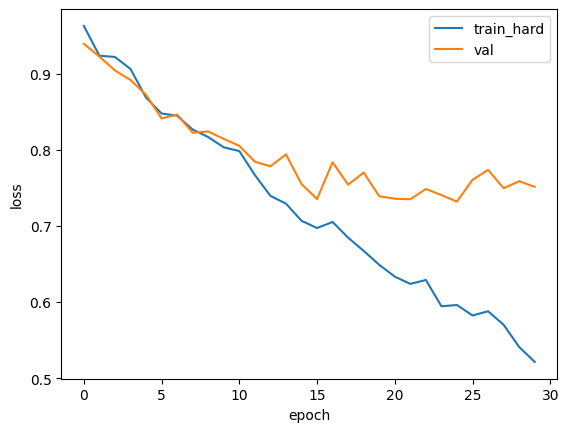

In [ ]:
# CELL 14
# ORCHESTRATING KD RUN

from pathlib import Path
from datetime import datetime
import torch

# load trained teacher checkpoint
T_CKPT_FILE_NAME = "epoch_005_round_003_1770036394.pt"
T_CKPT_PATH = f"{T_CKPT_DIR}/{T_CKPT_FILE_NAME}" # T_CKPT_DIR already defined
# load teacher checkpoint
trained_teacher_ckpt = torch.load(T_CKPT_PATH, map_location=device)
model_t.load_state_dict(trained_teacher_ckpt["model_state_dict"], strict=True)

model_t.eval()
for p in model_t.parameters():
    p.requires_grad_(False)

# creating checkpoint dir
timestamp = datetime.now().strftime("%Y-%m-%d_%H-%M-%S")
CKPT_DIR = Path(f"/content/drive/MyDrive/{my_drive_folder}/checkpoints/{timestamp}_student_run")
CKPT_DIR.mkdir(parents=True, exist_ok=True)
print("Checkpoint directory created at", CKPT_DIR)

# choose epoch count
"""
important note: warmup for OHEM takes 11 epochs to fully take place
"""
num_epochs = 30

# threshold sweep
thresholds = [0.25, 0.5, 0.7]
assert len(thresholds) > 0

train_hard_losses = []
val_losses = []

for epoch in range(num_epochs):
    # OHEM warmup schedule
    if epoch <= 5:
        hard_loss.neg_ohem_weight = 0.0
    elif epoch <= 7:
        hard_loss.neg_ohem_weight = 0.01
    elif epoch <= 9:
        hard_loss.neg_ohem_weight = 0.035
    else:
        hard_loss.neg_ohem_weight = 0.05

    # run training
    train_loss = train_one_epoch(
        model_s,
        model_t,
        train_loader,
        criterion_s,
        optimizer_s,
        device
    )
    train_total_loss = train_loss["train_total_loss"]
    train_hard_loss = train_loss["train_hard_loss"]
    train_soft_loss = train_loss["train_soft_loss"]

    # append training loss to list
    train_hard_losses.append(train_loss["train_hard_loss"])

    for t in thresholds:
        # run validation
        val_results = validate_one_epoch(model_s, val_loader, hard_loss, device, threshold=t)

        if t == thresholds[0]:
            # get the val loss for that epoch
            # note: any threshold is fine, but only one must be chosen; I chose the first
            val_loss = val_results["val_loss"]

            # append loss
            val_losses.append(val_loss)

            # step LR scheduler
            scheduler_s.step(train_hard_loss)

            # print epoch # and losses (printed once every epoch)
            print(
                "-------\n"
                f"EPOCH {epoch+1}/{num_epochs} | "
                f"TRAIN LOSS (H, S, T)={train_hard_loss:.4f}, {train_soft_loss:.4f}, {train_total_loss:.4f} | "
                f"VAL LOSS={val_results['val_loss']:.4f} | "
                f"LR={optimizer_s.param_groups[0]['lr']} | "
                f"OHEM WEIGHT={hard_loss.neg_ohem_weight}"
            )

        # print metrics (printed once per threshold value every epoch)
        print(
            f"THRESHOLD={t}\n"
            f"DSC={val_results['val_dsc']:.4f} | "
            f"IoU={val_results['val_iou']:.4f} | "
            f"FPIR={val_results['val_fpir']:.4f} | "
            f"FPHW={val_results['val_fphw']:.6f}"
        )


    # mask PNGs
    save_random_val_preds(
        model,
        val_ds,
        device,
        out_dir=str(CKPT_DIR / "viz"),
        epoch=epoch+1,
        n=7,
        threshold=0.5
    )

    # save basic checkpoints every 5 epochs
    if (epoch + 1) % 4 == 0:
        torch.save({
            "epoch": epoch + 1,
            "model_state_dict": model_s.state_dict(),
            "optimizer_state_dict": optimizer_s.state_dict(),
            "val_metrics": val_results,
        },
        CKPT_DIR / f"epoch_{epoch+1:03d}.pt")

# ----------------- PLOTTING EPOCH LOSS CURVES

import matplotlib.pyplot as plt

plt.figure()
plt.plot(train_hard_losses, label="train_hard")
plt.plot(val_losses, label="val")
plt.xlabel("epoch")
plt.ylabel("loss")
plt.legend()
plt.show()